In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
data= pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\ft\project\ML Project - Logistic Regression Titanic Survival U16955478860.txt")

In [3]:
data.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [4]:
#  print all the column names
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [5]:
# describe the data 
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# check the null value
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
# if there are Null values, Handle these
data['Age'] = data['Age'].fillna(data['Age'].median())

In [8]:
data.drop("Cabin",axis=1,inplace=True)

In [9]:
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

In [10]:
data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [11]:
data= pd.get_dummies(data,columns=['Sex','Embarked'],drop_first=True)

In [12]:
data.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)

In [13]:
x = data.drop("Survived",axis=1)
y= data["Survived"]

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=0)

In [16]:
print(x_train.shape)
print(x_test.shape)

(712, 8)
(179, 8)


In [17]:
# Create a Logistic regression model for Target and feature data
from sklearn.linear_model import LogisticRegression

In [18]:
model = LogisticRegression()

In [19]:
model.fit(x_train,y_train)

LogisticRegression()

In [20]:
model.score(x_train,y_train)

0.8033707865168539

In [21]:
model.score(x_test,y_test)

0.7821229050279329

In [22]:
y_pred = model.predict(x_test)

In [23]:
# Display the Confusion Matrix, Find the Accuracy Score, Find the Precision Score, Find the Recall Score, 
 #Find the F1 Score, Find the probability of testing data
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

In [24]:
print("Accuracy Score : ",accuracy_score(y_test,y_pred))
print("Precision Score : ",precision_score(y_test,y_pred))
print("Recall Score : ",recall_score(y_test,y_pred))
print("F1 Score : ",f1_score(y_test,y_pred))

Accuracy Score :  0.7821229050279329
Precision Score :  0.734375
Recall Score :  0.6811594202898551
F1 Score :  0.706766917293233


In [25]:
confusion_matrix(y_test,y_pred)

array([[93, 17],
       [22, 47]], dtype=int64)

In [26]:
# Find the probability of testing data , Display ROC Curve and find the AUC score
y_prob = model.predict_proba(x_test)
print(y_prob)

[[0.87701791 0.12298209]
 [0.86223782 0.13776218]
 [0.92360449 0.07639551]
 [0.0884254  0.9115746 ]
 [0.38820994 0.61179006]
 [0.54626296 0.45373704]
 [0.07178394 0.92821606]
 [0.06172109 0.93827891]
 [0.59754258 0.40245742]
 [0.35567036 0.64432964]
 [0.89657148 0.10342852]
 [0.22987996 0.77012004]
 [0.82831573 0.17168427]
 [0.11224676 0.88775324]
 [0.07084517 0.92915483]
 [0.23907913 0.76092087]
 [0.84336591 0.15663409]
 [0.75674481 0.24325519]
 [0.88422991 0.11577009]
 [0.78037975 0.21962025]
 [0.67986389 0.32013611]
 [0.04440256 0.95559744]
 [0.82832298 0.17167702]
 [0.54575715 0.45424285]
 [0.28172038 0.71827962]
 [0.13383617 0.86616383]
 [0.87517743 0.12482257]
 [0.28344747 0.71655253]
 [0.1650112  0.8349888 ]
 [0.42854182 0.57145818]
 [0.89395763 0.10604237]
 [0.2867072  0.7132928 ]
 [0.8612898  0.1387102 ]
 [0.54120072 0.45879928]
 [0.90458178 0.09541822]
 [0.61282548 0.38717452]
 [0.9063215  0.0936785 ]
 [0.73973341 0.26026659]
 [0.7207478  0.2792522 ]
 [0.85537866 0.14462134]


In [27]:
from sklearn.metrics import roc_curve, roc_auc_score

Text(0.5, 1.0, 'ROC Curve ')

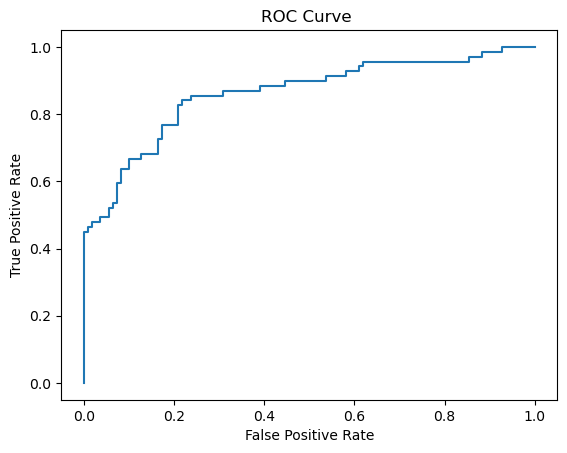

In [28]:
y_prob = model.predict_proba(x_test)[:,1]
# fpr - False Positive Rate
# tpr - True Positive Rate 
fpr, tpr, thresholds = roc_curve(y_test,y_prob)

plt.plot(fpr,tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC Curve ")

In [29]:
auc = roc_auc_score(y_test,y_prob)
print("AUC SCore : ", auc)

AUC SCore :  0.861528326745718
